# Lines

In [1]:
import meep as mp
from matplotlib import pyplot as plt
import numpy as np

In [2]:
cell = mp.Vector3(3, 3, 0)
resolution = 30

In [3]:
def test_geom(position):
    if position.y == position.x or position.y == -position.x:
        return mp.Medium(epsilon=5)
    if -0.3 <= position.y <= 0.3:
        return mp.Medium(epsilon=5)
    return mp.air

test_geom.do_averaging = True

geometry = []
geometry.append(mp.Block(center=mp.Vector3(),
                         size=mp.Vector3(2,2,0),    # Set the GeometricObject has the same size as the cell
                         material=test_geom))

     block, center = (0,0,0)
          size (2,2,0)
          axes (1,0,0), (0,1,0), (0,0,1)


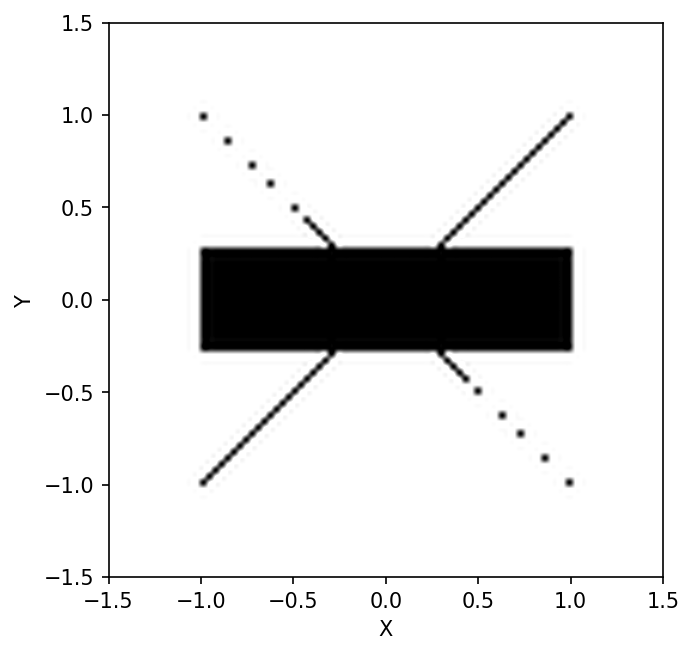

In [4]:
sim = mp.Simulation(cell_size=cell,
                    geometry=geometry,
                    # sources=sources,
                    resolution=resolution)

f = plt.figure(dpi=150)
sim.plot2D(ax=f.gca())
plt.show()

In [5]:
sim.init_sim()

-----------
Initializing structure...
time for choose_chunkdivision = 2.7895e-05 s
Working in 2D dimensions.
Computational cell is 3 x 3 x 0 with resolution 30
     block, center = (0,0,0)
          size (2,2,0)
          axes (1,0,0), (0,1,0), (0,0,1)
time for set_epsilon = 1.44338 s
-----------


<class 'numpy.ndarray'>
(90, 90)


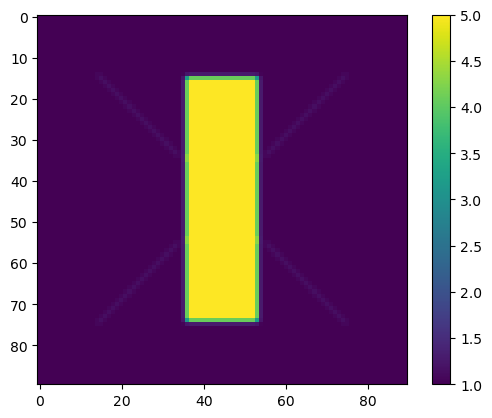

In [6]:
eps_data = sim.get_array(center=mp.Vector3(), size=cell, component=mp.Dielectric)
print(type(eps_data))
print(eps_data.shape)

plt.imshow(eps_data)
plt.colorbar()